# Bài tập Buổi 5 — Pipeline Machine Learning: EDA & Tiền xử lý trên Titanic

**Khóa học hè 2026 — Python & Machine Learning · ML IoT Lab, HCMUT**

---

## Bối cảnh

Bạn vừa nhận được dataset **Titanic** — danh sách hành khách và việc họ có sống sót sau thảm họa hay không.
Nhiệm vụ của bạn **không phải** huấn luyện mô hình, mà là hoàn thành **hai bước đầu và quan trọng nhất** của một dự án Machine Learning:

> **Khám phá dữ liệu (EDA) → Tiền xử lý dữ liệu.**

Đây là phần chiếm ~70–90% công sức thực tế của một dự án ML. Một mô hình mạnh không thể cứu một bộ dữ liệu kém chất lượng.

## Mục tiêu bài tập

Sau khi hoàn thành, bạn sẽ chứng minh được rằng mình có thể:

1. Thực hiện **EDA đầy đủ** trên một dataset thực tế: kiểm tra cấu trúc, giá trị thiếu, outlier, phân phối và tương quan.
2. **Trực quan hóa** dữ liệu và **rút ra nhận xét có căn cứ** (không chỉ vẽ hình cho đẹp).
3. Áp dụng **đúng kỹ thuật tiền xử lý** cho từng loại dữ liệu: xử lý missing, encoding, scaling.
4. Chia tập và xây pipeline tiền xử lý **không rò rỉ dữ liệu (data leakage)**.
5. Viết **nhận xét tổng hợp** về dữ liệu như một data analyst thực thụ.

## Yêu cầu nộp bài

- Hoàn thiện notebook này (điền vào tất cả các ô `# TODO` và các phần *"Trả lời:"*).
- Notebook phải **chạy được từ trên xuống dưới không lỗi** (Kernel → Restart & Run All).
- Nộp qua **GitHub**: tải repo mẫu → đưa lên repo cá nhân → làm bài và nộp trên đó.

## Tiêu chí chấm (10 điểm)

| Nội dung | Điểm |
|---|---|
| EDA đầy đủ (shape/info/missing/outlier) | 2.0 |
| Trực quan hóa + nhận xét cho mỗi biểu đồ | 2.0 |
| Xử lý missing & outlier hợp lý, có giải thích | 1.5 |
| Encoding & scaling đúng loại biến | 1.5 |
| Chia tập & tiền xử lý **không leakage** | 1.5 |
| Nhận xét tổng hợp về dữ liệu | 1.5 |

> **Lưu ý về liêm chính học thuật:** được tham khảo tài liệu, nhưng phải **tự viết code và tự hiểu**. Phần nhận xét phải là quan sát của chính bạn từ dữ liệu.

---


## 0. Chuẩn bị môi trường

Ô này đã viết sẵn — chạy để nạp thư viện. Nếu thiếu thư viện, cài bằng `pip install pandas numpy matplotlib seaborn scikit-learn`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler, StandardScaler

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
np.random.seed(42)          # cố định ngẫu nhiên -> kết quả tái lập được
print("Sẵn sàng.")

Sẵn sàng.


## 1. Tải dữ liệu (đã cho)

Ô này đã viết sẵn. Dữ liệu được tải từ `seaborn`, có fallback tải từ Internet nếu cần.

In [2]:
try:
    df = sns.load_dataset("titanic")
    print("Đã tải từ seaborn.")
except Exception:
    url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
    df = pd.read_csv(url)
    df.columns = [c.lower() for c in df.columns]
    print("Đã tải từ URL.")
df.head()

Đã tải từ seaborn.


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


---
## Task 1 — Loại bỏ cột rò rỉ nhãn (data leakage) và cột dư thừa

### Mục đích
Trên slide đã học: **data leakage** là khi thông tin không được phép "rò" vào mô hình, khiến kết quả đẹp trên giấy nhưng vô dụng thực tế. Bản Titanic của seaborn chứa sẵn nhiều cột **rò rỉ nhãn** hoặc **trùng lặp**:

- `alive` (yes/no) — chính là `survived` viết bằng chữ ⇒ **rò rỉ target trực tiếp**. Để lại là mô hình "gian lận".
- `who`, `adult_male`, `class` — được suy ra từ `sex`, `age`, `pclass` (trùng thông tin).
- `deck` — thiếu quá nhiều (~77%).
- `embark_town` — trùng `embarked`; `alone` — suy ra từ `sibsp` + `parch`.

### Yêu cầu
1. In ra danh sách cột và tỷ lệ missing của **toàn bộ** dataframe (để thấy `deck` thiếu bao nhiêu).
2. Loại bỏ các cột rò rỉ / dư thừa ở trên, chỉ giữ lại:
   `survived, pclass, sex, age, sibsp, parch, fare, embarked`.
3. **Trả lời** (markdown ô dưới): vì sao để lại cột `alive` sẽ khiến mô hình đạt accuracy ~100% mà không thực sự học được gì?

### Gợi ý
- `df.isnull().mean()` cho tỷ lệ thiếu theo cột.
- `df.drop(columns=[...])` để bỏ cột.

In [3]:
# TODO 1a: in tỷ lệ missing của tất cả các cột
print("Tỷ lệ missing của các cột:")
print(df.isnull().mean())
print("\n")

# TODO 1b: bỏ các cột rò rỉ/dư thừa, gán lại vào biến df
leaky = ['class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']
df = df.drop(columns=leaky)

print("Các cột còn lại:", list(df.columns))

Tỷ lệ missing của các cột:
survived       0.000000
pclass         0.000000
sex            0.000000
age            0.198653
sibsp          0.000000
parch          0.000000
fare           0.000000
embarked       0.002245
class          0.000000
who            0.000000
adult_male     0.000000
deck           0.772166
embark_town    0.002245
alive          0.000000
alone          0.000000
dtype: float64


Các cột còn lại: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']


**Trả lời 1c (vì sao `alive` gây rò rỉ target):**

Giữ lại cột alive sẽ gây rò rỉ dữ liệu (data leakage) vì:

+ alive ('yes'/'no') thực chất là bản sao trực tiếp của biến mục tiêu survived (1/0).

+ Thuật toán sẽ học vẹt quy luật yes -> 1 để đạt độ chính xác 100% ảo mà phớt lờ các đặc trưng thật sự (age, pclass, sex...).

+ Khi dự đoán một hành khách mới, ta hoàn toàn chưa biết trạng thái alive của họ để đưa vào mô hình.

---
## Task 2 — Quan sát tổng quan

### Mục đích
Trước khi phân tích sâu, phải nắm được "hình dạng" của dữ liệu: bao nhiêu mẫu, bao nhiêu đặc trưng, kiểu dữ liệu từng cột, và thống kê cơ bản. Đây là bước đầu tiên của mọi EDA.

### Yêu cầu
1. In **số dòng và số cột**; nêu rõ đâu là **biến mục tiêu (target)**.
2. Dùng `df.info()` để xem kiểu dữ liệu và số giá trị non-null.
3. Dùng `df.describe()` cho biến số và `df.describe(include="object")` (hoặc `"category"`) cho biến phân loại.
4. **Trả lời:** cột nào là biến **số**, cột nào là biến **phân loại**?

In [4]:
# TODO 2: shape, info, describe
print(f"Kích thước dữ liệu: {df.shape[0]} dòng, {df.shape[1]} cột.")
print("Biến mục tiêu (target) là: survived")
df.info()
print("\n")
display(df.describe())
display(df.describe(exclude='number'))

Kích thước dữ liệu: 891 dòng, 8 cột.
Biến mục tiêu (target) là: survived
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int64  
 1   pclass    891 non-null    int64  
 2   sex       891 non-null    str    
 3   age       714 non-null    float64
 4   sibsp     891 non-null    int64  
 5   parch     891 non-null    int64  
 6   fare      891 non-null    float64
 7   embarked  889 non-null    str    
dtypes: float64(2), int64(4), str(2)
memory usage: 55.8 KB




,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


,sex,embarked
count,891,889
unique,2,3
top,male,S
freq,577,644


**Trả lời 2 (biến số vs biến phân loại):**

Biến số (Numerical Variables):

+ Liên tục: age, fare.

+ Rời rạc: sibsp, parch.

Biến phân loại (Categorical Variables):

+ Định danh (Nominal): sex, embarked.

+ Thứ bậc (Ordinal): pclass.

Biến mục tiêu (Target): survived, cũng là một biến phân loại dạng nhị phân.

---
## Task 3 — Missing Value: thống kê & đề xuất cách xử lý

### Mục đích
Mô hình học máy **không nhận trực tiếp giá trị NaN**. Nhưng cách xử lý phụ thuộc **tỷ lệ thiếu** và **vai trò của cột** — không có một cách đúng cho mọi trường hợp.

### Yêu cầu
1. Lập bảng: mỗi cột còn missing → **số lượng** và **phần trăm** thiếu.
2. Với **từng cột** còn thiếu, **đề xuất** cách xử lý và **giải thích ngắn gọn** (xóa / điền mean / điền median / điền mode / KNN...).

### Gợi ý
- Nhắc lại từ slide: `median` bền vững hơn `mean` khi có outlier; cột thiếu quá nhiều (>~60–70%) thường nên **bỏ**; biến phân loại thường điền **mode**.

In [5]:
# TODO 3: bảng missing (count + %)
missing_count = df.isnull().sum()
missing_percent = df.isnull().mean() * 100
missing_df = pd.DataFrame({
    'Số lượng thiếu': missing_count,
    'Phần trăm thiếu (%)': missing_percent
})
missing_df = missing_df[missing_df['Số lượng thiếu'] > 0].sort_values(by='Phần trăm thiếu (%)', ascending=False)
display(missing_df)

,Số lượng thiếu,Phần trăm thiếu (%)
age,177,19.865320
embarked,2,0.224467


**Trả lời 3 (đề xuất xử lý cho từng cột thiếu):**

| Cột | % thiếu | Cách xử lý đề xuất | Lý do |
| :--- | :--- | :--- | :--- |
| `age` | ~19.87% | Điền giá trị trung vị  | `age` là biến số liên tục, tỷ lệ thiếu vừa phải (~20%, đủ để giữ lại cột). Tuy nhiên, cột này có thể chứa các giá trị ngoại lệ (outlier) như hành khách rất già. Dùng median sẽ mang lại tính bền vững cho dữ liệu hơn là dùng mean, giúp mô hình hội tụ tốt hơn mà không bị nhiễu bởi các giá trị cực đoan. |
| `embarked` | ~0.22% | Điền giá trị phổ biến nhất| `embarked` là biến phân loại (categorical). Tỷ lệ thiếu cực kỳ nhỏ (chỉ 2/891 mẫu). Theo nguyên tắc thông thường cho biến phân loại, việc điền bằng class xuất hiện nhiều nhất là an toàn và ít làm thay đổi phân phối gốc nhất. |

---
## Task 4 — Phát hiện Outlier & **ra quyết định**

### Mục đích
Outlier có thể là **lỗi nhập liệu** (cần xử lý) hoặc **hiện tượng thật** (cần giữ). Phát hiện thôi chưa đủ — một analyst giỏi phải **quyết định** làm gì và giải thích được.

### Yêu cầu
1. Trên hai cột `age` và `fare`, đếm số outlier bằng **cả hai** phương pháp: **IQR** và **Z-score** (ngưỡng |z| > 3).
2. **Trả lời:** với các outlier của `fare`, bạn **giữ lại hay loại bỏ**? Vì sao? (gợi ý: nghĩ xem vé đắt bất thường là lỗi hay là vé hạng nhất có thật).

### Gợi ý
- IQR: outlier là điểm ngoài khoảng `[Q1 - 1.5*IQR, Q3 + 1.5*IQR]`.
- Z-score: `from scipy import stats; np.abs(stats.zscore(series.dropna()))`.

In [6]:
# TODO 4: đếm outlier theo IQR và Z-score cho 'age' và 'fare'
def dem_outlier_iqr(s):
    s = s.dropna()
    Q1 = s.quantile(0.25)
    Q3 = s.quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = s[(s < lower_bound) | (s > upper_bound)]
    return len(outliers)

def dem_outlier_zscore(s, nguong=3.0):
    s = s.dropna()
    
    z_scores = np.abs(stats.zscore(s))
    
    outliers = s[z_scores > nguong]
    return len(outliers)

for col in ["age", "fare"]:
    print(f"--- Cột '{col}' ---")
    print(f"Số lượng outlier theo IQR    : {dem_outlier_iqr(df[col])}")
    print(f"Số lượng outlier theo Z-score: {dem_outlier_zscore(df[col])}\n")

--- Cột 'age' ---
Số lượng outlier theo IQR    : 11
Số lượng outlier theo Z-score: 2

--- Cột 'fare' ---
Số lượng outlier theo IQR    : 116
Số lượng outlier theo Z-score: 20



**Trả lời 4 (quyết định với outlier của `fare`):**

Giữ lại vì outlier trong cột fare phần lớn không phải là lỗi nhập liệu mà phản ánh đúng thực tế phân hóa trên tàu Titanic. Những vé có giá cao bất thường tương ứng với các phòng cao cấp ở khoang Hạng Nhất dành cho người giàu. Vì vậy chúng mang thông tin rất lớn và tỷ lệ thuận trực tiếp với xác suất sống sót (ví dụ như hành khách giàu có được ưu tiên lên thuyền cứu sinh). Nếu loại bỏ các dòng này, mô hình sẽ bị mất đi những đặc trưng quan trọng để dự đoán.

---
## Task 5 — Trực quan hóa & nhận xét

### Mục đích
EDA là môn học về **nhìn** dữ liệu. Mỗi biểu đồ phải trả lời một câu hỏi và **đi kèm một nhận xét**. Vẽ mà không nhận xét thì không tính điểm.

### Yêu cầu — vẽ tối thiểu 4 loại biểu đồ, mỗi biểu đồ 1–2 câu nhận xét:
1. **Univariate — Histogram**: phân phối của `age` và `fare`. (Nhận xét: có lệch không? lệch trái hay phải?)
2. **Univariate — Boxplot**: `fare` theo nhóm `survived` hoặc `pclass`. (Nhận xét: outlier, trung vị.)
3. **Bivariate — Bar/Barplot**: **tỷ lệ sống sót** theo `sex` và theo `pclass`. (Nhận xét: nhóm nào sống nhiều hơn, chênh bao nhiêu %?)
4. **Multivariate — Heatmap**: ma trận tương quan giữa các biến số. (Nhận xét: cặp biến nào tương quan mạnh?)

### Gợi ý
- `sns.histplot`, `sns.boxplot`, `sns.barplot(data=df, x="sex", y="survived")` (barplot tự tính trung bình = tỷ lệ sống sót), `sns.heatmap(df.select_dtypes("number").corr(), annot=True)`.

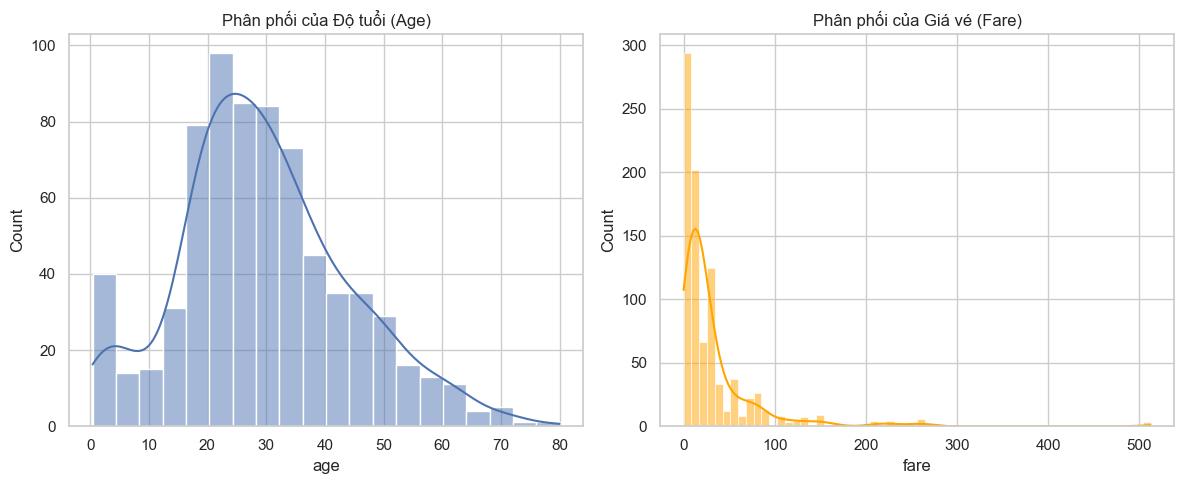

In [7]:
# TODO 5a: Histogram age & fare
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Biểu đồ Age
sns.histplot(data=df, x='age', kde=True, ax=axes[0])
axes[0].set_title('Phân phối của Độ tuổi (Age)')

# Biểu đồ Fare
sns.histplot(data=df, x='fare', kde=True, ax=axes[1], color='orange')
axes[1].set_title('Phân phối của Giá vé (Fare)')

plt.tight_layout()
plt.show()

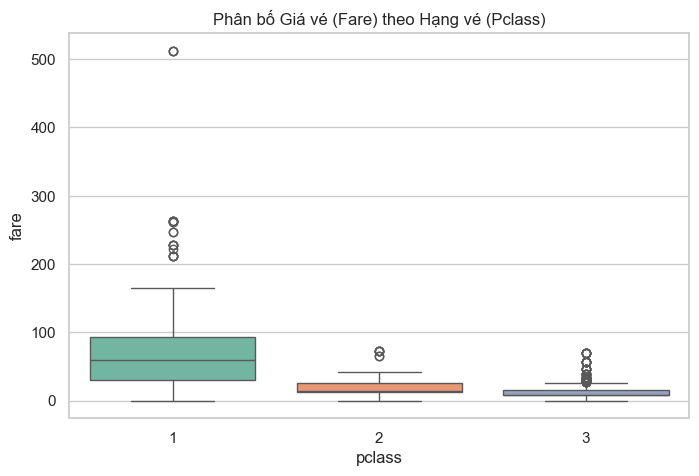

In [8]:
# TODO 5b: Boxplot fare theo survived hoặc pclass
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='pclass', y='fare', hue='pclass', palette='Set2', legend=False)
plt.title('Phân bố Giá vé (Fare) theo Hạng vé (Pclass)')
plt.show()

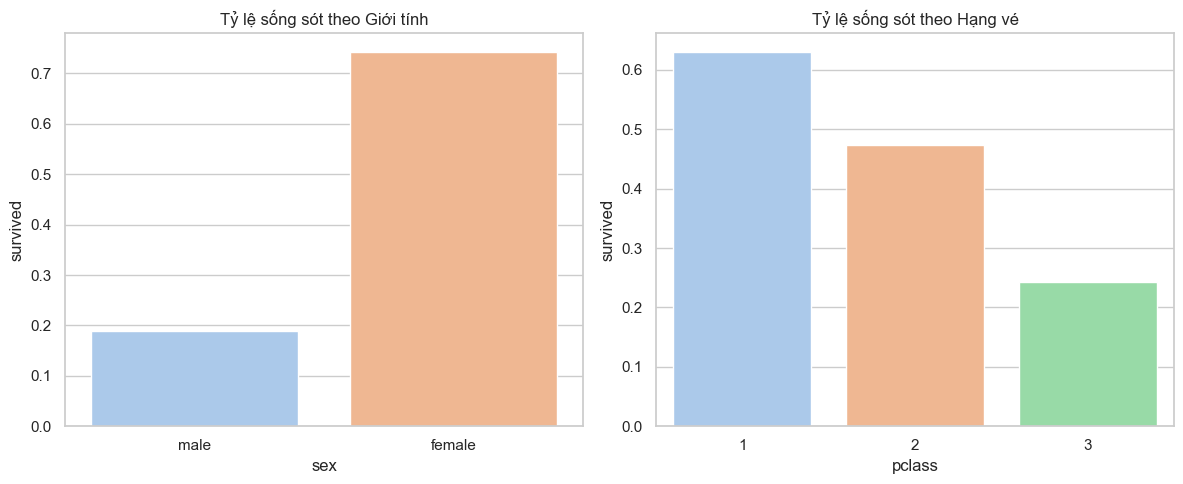

In [9]:
# TODO 5c: Barplot tỷ lệ sống sót theo sex và pclass
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Barplot theo sex
sns.barplot(data=df, x='sex', y='survived', ax=axes[0], errorbar=None, hue='sex', palette='pastel', legend=False)
axes[0].set_title('Tỷ lệ sống sót theo Giới tính')

# Barplot theo pclass
sns.barplot(data=df, x='pclass', y='survived', ax=axes[1], errorbar=None, hue='pclass', palette='pastel', legend=False)
axes[1].set_title('Tỷ lệ sống sót theo Hạng vé')

plt.tight_layout()
plt.show()

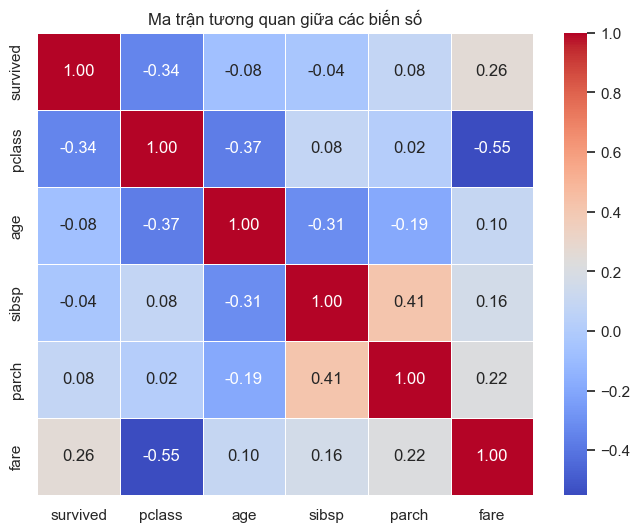

In [10]:
# TODO 5d: Heatmap correlation
plt.figure(figsize=(8, 6))

corr_matrix = df.select_dtypes(include='number').corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Ma trận tương quan giữa các biến số')
plt.show()

**Nhận xét 5 (viết cho từng biểu đồ ở trên):**

Histogram: 
+ Age: Phân phối có dạng khá giống phân phối chuẩn nhưng hơi lệch phải nhẹ. Phần lớn hành khách trên tàu tập trung ở độ tuổi thanh niên từ 20 đến 30 tuổi. Trẻ em (dưới 10 tuổi) cũng chiếm một lượng đáng kể.
+ Fare: Dữ liệu bị lệch phải rất mạnh. Đa số hành khách mua vé ở mức giá rất thấp (chủ yếu từ 0 - 50). Chỉ có một nhóm rất nhỏ mua vé với giá cực kỳ cao.

Boxplot:
+ Pclass = 1: Có mức giá vé trung vị cao nhất và mức độ phân tán dữ liệu lớn nhất. Khoảng giá trị trải dài và xuất hiện rất nhiều outlier có giá vé cực kỳ đắt đỏ (từ 200 đến hơn 500).
+  Pclass = 2 và 3: Giá vé trung vị thấp hơn hẳn và biên độ dao động cũng rất hẹp (tập trung chủ yếu ở mức dưới 50). Dù vẫn có các outlier, nhưng mức giá tối đa thấp hơn rất nhiều so với vé hạng 1.

Bar survival:
+ Theo sex: Yếu tố giới tính ảnh hưởng cực kỳ lớn đến khả năng sống sót. Nữ giới có tỷ lệ sống sót vượt trội (hơn 70%), trong khi nam giới có tỷ lệ sống sót rất thấp (chưa tới 20%).
+ Theo pclass: Tỷ lệ sống sót giảm dần theo mức độ sang trọng của hạng vé. Hành khách Hạng 1 có cơ hội sống sót cao nhất (trên 60%), tiếp đến là Hạng 2 (gần 50%) và thấp nhất là Hạng 3 (dưới 25%).

Heatmap:
+ Tương quan với biến survived: Khả năng sống sót có tương quan nghịch rõ rệt với pclass (-0.34) và tương quan thuận với fare (0.26). Điều này củng cố kết luận từ biểu đồ trước: người mua vé giá cao và ở hạng vé cao có khả năng sống sót cao hơn.

+ Tương quan giữa các đặc trưng: Cặp biến pclass và fare có tương quan nghịch mạnh nhất (-0.55), hoàn toàn hợp lý vì hạng vé càng cao (1) thì giá càng đắt. Cặp biến sibsp và parch có tương quan thuận khá tốt (0.41), cho thấy những hành khách đi cùng anh chị em/vợ chồng thường cũng đi cùng cha mẹ/con cái (đi theo diện gia đình).

---
## Task 6 — Chia tập **TRƯỚC** khi tiền xử lý (chống data leakage)

### Mục đích
Đây là điểm mấu chốt của buổi học. Mọi phép "học tham số" từ dữ liệu (median để điền, min/max/IQR để scale, danh mục để encode) **chỉ được học từ tập train**. Nếu học từ toàn bộ dữ liệu rồi mới chia, thông tin của tập test đã **rò rỉ** — điểm đánh giá sẽ ảo.

⇒ **Vì vậy phải chia tập TRƯỚC**, rồi mới xử lý.

### Yêu cầu
1. Tách `X` (đặc trưng) và `y` (`survived`).
2. Chia **train / validation / test** theo tỷ lệ khoảng **70 / 15 / 15**, có **`stratify=y`** để giữ nguyên tỷ lệ hai lớp.
3. In shape của 3 tập và **tỷ lệ sống sót** trong mỗi tập (để kiểm tra stratify hoạt động).

### Gợi ý
- Dùng `train_test_split` **hai lần**: lần 1 tách test (15%), lần 2 tách val từ phần còn lại.
- `stratify` nhận vào nhãn tương ứng ở mỗi lần chia.

In [11]:
# TODO 6: chia train/val/test có stratify
# 1. Tách X (đặc trưng) và y (survived)
X = df.drop(columns=['survived'])
y = df['survived']

# 2. Chia lần 1: Tách test (15%), còn lại 85% là tmp
X_tmp, X_test, y_tmp, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=42
)

# Chia lần 2: Tách tmp (85%) thành train (70%) và val (15%)
# Tỷ lệ cần lấy cho val từ tập tmp là 15/85
X_train, X_val, y_train, y_val = train_test_split(
    X_tmp, y_tmp, test_size=15/85, stratify=y_tmp, random_state=42
)

# 3. In shape của 3 tập
print("Kích thước các tập (Shape):")
print(f" - Train: {X_train.shape}")
print(f" - Val  : {X_val.shape}")
print(f" - Test : {X_test.shape}")

# In tỷ lệ survived từng tập để kiểm tra stratify hoạt động tốt không
print("\nTỷ lệ sống sót (survived) trong từng tập:")
print(f" - Train gốc : {y.mean():.4f}")
print(f" - Train set : {y_train.mean():.4f}")
print(f" - Val set   : {y_val.mean():.4f}")
print(f" - Test set  : {y_test.mean():.4f}")

Kích thước các tập (Shape):
 - Train: (623, 7)
 - Val  : (134, 7)
 - Test : (134, 7)

Tỷ lệ sống sót (survived) trong từng tập:
 - Train gốc : 0.3838
 - Train set : 0.3836
 - Val set   : 0.3881
 - Test set  : 0.3806


---
## Task 7 — Xây pipeline tiền xử lý, **fit chỉ trên train**

### Mục đích
Gộp toàn bộ bước tiền xử lý vào một `ColumnTransformer` + `Pipeline`, `fit` **một lần trên `X_train`** rồi `transform` cho val/test. Đây là cách chuẩn để **đảm bảo không leakage** và tái sử dụng được.

### Yêu cầu
Xây `preprocess` gồm:

- **Biến số** (`age`, `sibsp`, `parch`, `fare`): `SimpleImputer(median)` → scaler (chọn `RobustScaler` vì `fare` có outlier, hoặc giải thích lựa chọn khác).
- **Biến phân loại** (`sex`, `embarked`): `SimpleImputer(most_frequent)` → `OneHotEncoder`.
- **Biến thứ tự** (`pclass`): giữ nguyên (`passthrough`) vì đã là số có thứ tự 1 < 2 < 3.

Sau đó: `fit` trên `X_train`, `transform` cho cả ba tập; in shape kết quả và tên cột sau biến đổi.

### Yêu cầu trả lời
- **Trả lời:** giải thích vì sao `fit` chỉ trên train (không phải trên toàn bộ dữ liệu) thì tránh được leakage.

### Gợi ý
- Khung `ColumnTransformer([... ("num", pipe_so, num_cols), ("cat", pipe_cat, cat_cols), ("ord", "passthrough", ord_cols)])`.
- `preprocess.get_feature_names_out()` để xem tên cột sau biến đổi.

In [12]:
num_cols = ["age", "sibsp", "parch", "fare"]
cat_cols = ["sex", "embarked"]
ord_cols = ["pclass"]

# TODO 7: xây pipeline cho biến số và biến phân loại
pipe_so = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler())
])

pipe_cat = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    # handle_unknown='ignore' giúp tránh lỗi nếu tập val/test có hạng mục mới chưa từng xuất hiện ở train
    ("onehot", OneHotEncoder(handle_unknown='ignore', sparse_output=False)) 
])

preprocess = ColumnTransformer([
    ("num", pipe_so, num_cols),
    ("cat", pipe_cat, cat_cols),
    ("ord", "passthrough", ord_cols)
])

# Chỉ fit trên tập huấn luyện (X_train)
preprocess.fit(X_train)                  

# Transform cho cả 3 tập
X_train_t = preprocess.transform(X_train)
X_val_t = preprocess.transform(X_val)
X_test_t = preprocess.transform(X_test)

# In kết quả
print(f"Kích thước X_train_t: {X_train_t.shape}")
print("Các cột sau khi biến đổi:\n", list(preprocess.get_feature_names_out()))

Kích thước X_train_t: (623, 10)
Các cột sau khi biến đổi:
 ['num__age', 'num__sibsp', 'num__parch', 'num__fare', 'cat__sex_female', 'cat__sex_male', 'cat__embarked_C', 'cat__embarked_Q', 'cat__embarked_S', 'ord__pclass']


**Trả lời 7 (vì sao fit chỉ trên train tránh leakage):**

Vì fit là quá trình mô hình học các tham số thống kê từ dữ liệu. Nếu ta fit trên toàn bộ dữ liệu trước khi chia tập, các tham số thống kê này sẽ bị trộn lẫn cả thông tin của tập validation và tập test. Lúc này, mô hình đã vô tình biết trước được đặc tính của dữ liệu kiểm thử. Hậu quả là kết quả đánh giá trên tập test sẽ rất cao, nhưng khi mang ra áp dụng thực tế với dữ liệu hoàn toàn mới, mô hình sẽ hoạt động rất tệ.

---
## Task 8 — Câu hỏi tư duy: chọn metric đánh giá

### Mục đích
Buổi học nhấn mạnh: **không có metric tốt nhất tuyệt đối** — phải chọn theo bài toán và mức mất cân bằng dữ liệu. Bài này không cần code, chỉ cần lập luận.

### Yêu cầu — trả lời ngắn gọn:
1. Biến mục tiêu `survived` có **mất cân bằng** không? (tính tỷ lệ hai lớp để trả lời).
2. Nếu chỉ nhìn **Accuracy**, có thể bị đánh lừa trong trường hợp nào?
3. Với bài toán Titanic, bạn sẽ ưu tiên metric nào (Accuracy / Precision / Recall / F1)? Vì sao?

In [13]:
# TODO 8: tính tỷ lệ hai lớp của 'survived' để hỗ trợ trả lời
print("Số lượng mẫu mỗi lớp:")
print(df['survived'].value_counts())

print("\nTỷ lệ phần trăm (%):")
print(df['survived'].value_counts(normalize=True) * 100)

Số lượng mẫu mỗi lớp:
survived
0    549
1    342
Name: count, dtype: int64

Tỷ lệ phần trăm (%):
survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64


**Trả lời 8:**

1. Có mất cân bằng nhẹ. Theo kết quả tính toán, tỷ lệ lớp 0 chiếm ~61.6% và lớp 1 chiếm ~38.4%.
2. Khi dữ liệu mất cân bằng. Mô hình có thể dự đoán lớp đa số. Ở bài này, nếu mô hình đoán tất cả đều là 0 thì Accuracy vẫn đạt 61.6% dù thực chất mô hình không học được gì.
3. Ưu tiên F1-Score. Vì dữ liệu có sự mất cân bằng, F1 (trung bình của Precision và Recall) sẽ đánh giá đúng thực lực của mô hình trên cả hai lớp một cách toàn diện hơn, thay vì chỉ đo tỷ lệ đoán trúng chung chung như Accuracy.

---
## Task 9 — Nhận xét tổng hợp về dữ liệu

### Mục đích
Khép lại toàn bộ EDA bằng một bản tóm tắt như một data analyst gửi cho đồng đội: **những gì đáng chú ý nhất** về bộ dữ liệu này.

### Yêu cầu — viết ít nhất 5 gạch đầu dòng, dựa trên **bằng chứng** (số liệu / biểu đồ) ở trên:
- Đặc trưng nào **tương quan mạnh nhất** với khả năng sống sót? (số liệu chứng minh)
- Cột nào **thiếu nhiều nhất** và bạn đã xử lý thế nào?
- Biến mục tiêu có **mất cân bằng** không? ảnh hưởng gì tới việc chọn metric?
- Đặc trưng nào cần **scaling**, đặc trưng nào cần **encoding**? vì sao?
- Một điều bạn thấy **bất ngờ / thú vị** trong dữ liệu.

**Nhận xét tổng hợp của bạn:**

1. Đặc trưng tương quan mạnh nhất với khả năng sống sót: sex và pclass.

Bằng chứng: Biểu đồ Barplot cho thấy tỷ lệ sống của nữ (>70%) áp đảo nam (<20%). Heatmap chỉ ra pclass có tương quan nghịch mạnh nhất (-0.34) với biến survived (vé hạng càng cao/số càng nhỏ thì tỷ lệ sống càng lớn).

2. Cột thiếu dữ liệu nhiều nhất: Cột deck thiếu trầm trọng nhất (~77%) nên đã bị loại bỏ hoàn toàn ở Task 1. Trong các biến được giữ lại, age thiếu nhiều nhất (~19.8%) và đã được xử lý bằng cách điền giá trị median để đảm bảo tính bền vững, không bị kéo lệch bởi các outlier về tuổi.

3. Biến survived có sự mất cân bằng nhẹ (lớp 0 chiếm ~61.6%, lớp 1 chiếm ~38.4%). Điều này dẫn đến việc metric Accuracy có thể bị đánh giá cao quá khả năng dự đoán của mô hình; do đó cần ưu tiên sử dụng F1-Score để đánh giá hiệu suất một cách toàn diện và chính xác hơn.

4. + Scaling: Cần áp dụng cho biến số (age, fare, sibsp, parch) để đưa các đặc trưng về cùng thang đo, tránh việc mô hình ưu ái các cột có giá trị lớn.
+ Encoding: Cần áp dụng One-Hot Encoding cho các biến phân loại định danh (sex, embarked) để chuyển văn bản thành số (0 và 1) mà không vô tình tạo ra thứ tự độ lớn giả tạo cho thuật toán học.

5. Các outlier khổng lồ ở cột fare lớn hơn 500 không phải là lỗi nhập liệu mà là minh chứng lịch sử thực tế cho giới siêu giàu ở khoang Hạng Nhất. Chính sự phân hóa giàu nghèo này lại là một trong những tín hiệu dự đoán sống sót mạnh mẽ nhất của bộ dữ liệu.

---
## (Bonus — không bắt buộc) Thử thách nâng cao

Chọn **một** trong các hướng sau nếu bạn muốn thử sức:

1. **Feature engineering:** tạo đặc trưng mới `family_size = sibsp + parch + 1`, hoặc trích `title` (Mr/Mrs/Miss...) từ tên (nếu dùng bản có cột `name`). Kiểm tra tương quan với `survived`.
2. **So sánh scaler:** vẽ phân phối `fare` trước và sau khi áp `StandardScaler`, `MinMaxScaler`, `RobustScaler`. Nhận xét scaler nào phù hợp nhất với dữ liệu lệch + có outlier.
3. **Bẫy KNN:** thử `KNNImputer` để điền `age` **khi chưa scale** và **sau khi đã scale** `fare`. Quan sát kết quả có khác nhau không, và giải thích tại sao (gợi ý: khoảng cách Euclid bị chi phối bởi cột thang đo lớn).

1. FEATURE ENGINEERING
Độ tương quan giữa family_size và survived: 0.0166


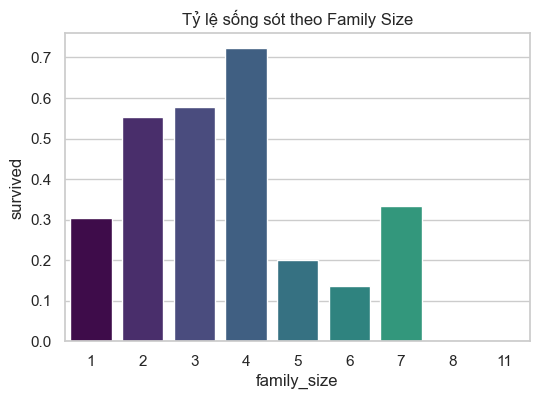

In [14]:
# (tùy chọn) code cho phần Bonus
print("1. FEATURE ENGINEERING")
df['family_size'] = df['sibsp'] + df['parch'] + 1
corr_family = df[['family_size', 'survived']].corr().iloc[0, 1]
print(f"Độ tương quan giữa family_size và survived: {corr_family:.4f}")

plt.figure(figsize=(6, 4))
sns.barplot(data=df, x='family_size', y='survived', errorbar=None, palette='viridis', hue='family_size', legend=False)
plt.title('Tỷ lệ sống sót theo Family Size')
plt.show()

+ Tương quan tuyến tính (Pearson) giữa family_size và survived khá thấp (quanh mức 0.01), biểu đồ trên cho thấy mối quan hệ là phi tuyến tính.
+ Hành khách đi một mình (family_size = 1) hoặc đi gia đình quá đông (family_size > 4) có tỷ lệ sống sót thấp. Trái lại, các gia đình nhỏ và vừa (2 đến 4 người) có tỷ lệ sống sót cao nhất.

2. SO SÁNH SCALER 


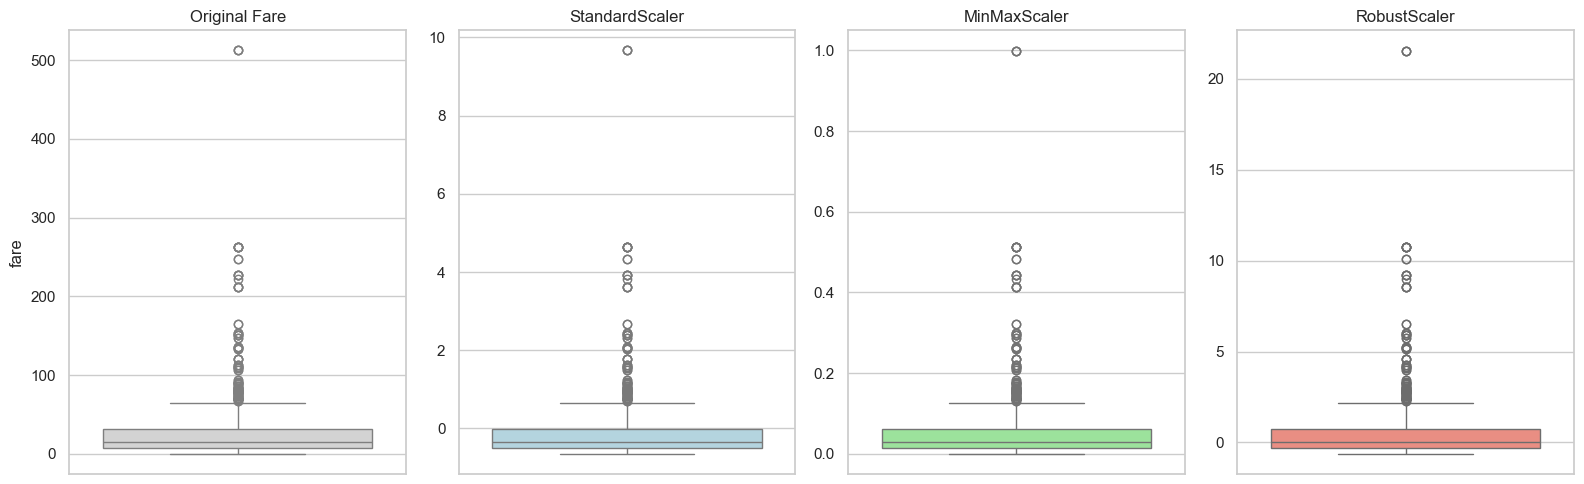

In [15]:
print("2. SO SÁNH SCALER ")
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

fare_data = df[['fare']].copy()

fare_std = StandardScaler().fit_transform(fare_data)
fare_minmax = MinMaxScaler().fit_transform(fare_data)
fare_robust = RobustScaler().fit_transform(fare_data)

fig, axes = plt.subplots(1, 4, figsize=(16, 5))

sns.boxplot(y=fare_data['fare'], ax=axes[0], color='lightgray').set_title('Original Fare')
sns.boxplot(y=fare_std.flatten(), ax=axes[1], color='lightblue').set_title('StandardScaler')
sns.boxplot(y=fare_minmax.flatten(), ax=axes[2], color='lightgreen').set_title('MinMaxScaler')
sns.boxplot(y=fare_robust.flatten(), ax=axes[3], color='salmon').set_title('RobustScaler')

for ax in axes:
    ax.yaxis.grid(True)

plt.tight_layout()
plt.show()

+ MinMaxScaler: Chuẩn hóa toàn bộ dữ liệu về khoảng [0, 1]. Do outlier > 500 là quá lớn, toàn bộ phân bố của IQR bị nén chặt về sát mốc 0. Điều này làm suy giảm phương sai (variance) của nhóm dữ liệu chính, khiến mô hình khó phân biệt được sự khác nhau giữa các hành khách thông thường.
+ StandardScaler: Chuẩn hóa phân bố về kỳ vọng bằng 0 và độ lệch chuẩn bằng 1. Tuy nhiên, do giá trị trung bình không bền vững và bị các outlier kéo lệch mạnh về phía dương, trọng tâm thực tế của dữ liệu bị đẩy hẳn xuống vùng giá trị âm. Điều này làm sai lệch cấu trúc phân bố thực tế.
+ RobustScaler: Sử dụng các đại lượng thống kê như Median và IQR để chuẩn hóa. Nhờ đó, trọng tâm dữ liệu được căn chuẩn chính xác tại mốc 0, phần thân hộp được giữ nguyên biên độ, loại bỏ hoàn toàn hiện tượng nhiễu từ các điểm ngoại lai. Đây là phương pháp tối ưu nhất cho bài toán này.

In [16]:
print("3. BẪY KNN IMPUTER")
from sklearn.impute import KNNImputer

df_knn = df[['age', 'fare']].copy()

knn_unscaled = KNNImputer(n_neighbors=5)
df_unscaled_imputed = pd.DataFrame(knn_unscaled.fit_transform(df_knn), columns=['age', 'fare'])

df_knn_scaled = df_knn.copy()
df_knn_scaled['fare'] = MinMaxScaler().fit_transform(df_knn[['fare']]) # Ép fare về [0, 1]
knn_scaled = KNNImputer(n_neighbors=5)
df_scaled_imputed = pd.DataFrame(knn_scaled.fit_transform(df_knn_scaled), columns=['age', 'fare'])

nan_idx = df_knn[df_knn['age'].isnull()].index[:5]
comparison = pd.DataFrame({
    'Fare gốc': df_knn.loc[nan_idx, 'fare'],
    'Age điền (CHƯA Scale Fare)': df_unscaled_imputed.loc[nan_idx, 'age'],
    'Age điền (ĐÃ Scale Fare)': df_scaled_imputed.loc[nan_idx, 'age']
})
display(comparison)

3. BẪY KNN IMPUTER


,Fare gốc,Age điền (CHƯA Scale Fare),Age điền (ĐÃ Scale Fare)
5,8.4583,22.684,22.684
17,13.0000,34.600,34.600
19,7.2250,31.100,31.100
26,7.2250,31.100,31.100
28,7.8792,28.800,30.400


---
## Bảng tự kiểm trước khi nộp

- [ ] Notebook chạy **Restart & Run All** không lỗi.
- [ ] Đã bỏ các cột rò rỉ/dư thừa (Task 1) và giải thích được vì sao.
- [ ] Mỗi biểu đồ (Task 5) đều có **nhận xét**.
- [ ] Đã **chia tập trước**, tiền xử lý **fit chỉ trên train** (Task 6–7).
- [ ] Đã trả lời tất cả các phần *"Trả lời:"*.
- [ ] Nhận xét tổng hợp (Task 9) có **ít nhất 5 ý** dựa trên bằng chứng.
- [ ] Đã push lên **repo cá nhân trên GitHub**.
